# 4.6 가설 검정

- 두 독립 집단의 시험 점수를 예로 들어, **관측된 차이가 우연한 표집오차인지**</br>
**실제 모집단의 차이인지** 판단하는 방법을 다룸
- 핵심 도구는 모수적인 방법인 **t-검정**과 비모수적 방법인 **맨-휘트니 U 검정**이다.

## 4.6.1 가설
- 가설 검정은 다음 두 가설을 비교한다.
- **귀무 가설 또는 영가설(null hypothesis) $H_0$** :
    - 두 데이터 집합이 **사실은 같은** 모집단에서 나왔을거다
    - 제안하거나 증명하고자 하는 것이 실제로는 아무런 효과 및 관련이 없음을 가정하는 가설

- **대안가설(alternative hypothesis) $H_a$** :
    - 두 그룹이 같은 모집단에서 나온 것이 아니다
    - 귀무가설의 반대되는 말로 제안하더나 증명하고자 하는 것이 실제로는 있음을 가정하는 가설

- $H_0$를 기각했다는 뜻은 “평균이 같다는 가정과 잘 맞지 않는 증거가 있다”는 것이지, $H_a$가 절대적으로 참이라고 증명한 것은 아님
- 이번 예제에서는 방향을 미리 정하지 않으므로 **양측 검정**을 사용함
- 기본 가정:
    1) 두 표본은 서로 독립이다.
    2) 두 집단의 분산이 같을 필요는 없다.
    3) 표본으로 모집단 평균과 표준편차를 추정한다.
    4) 관측값은 독립 동일 분포(i.i.d.)로 생성되었다고 본다.

## 4.6.2 t-검정
- t-검정은 두 집단 평균의 차이를 검정하는 모수적 검정
- 데이터가 대체로 정규분포를 따른다는 가정에 기반함
- 이 절에서는 분산이 같다고 가정하지 않는 Welch t-검정을 사용
$$
    t = \frac
    {\bar{x}_1 - \bar{x}_2}
    {\sqrt{
        \frac{s_1^2}{n_1}
        +
        \frac{s_2^2}{n_2}
    }}
$$
- 계산된 $t$값을 t-분포와 비교해 $p$값을 구함
- $p$값은 "귀무가설이 참이라고 가정할 때, 현재 관측한 차이 또는 그보다 큰 차이가 나올 가능성"이다
- $p<\alpha$이면 귀무가설은 기각. 흔히 $\alpha=0.05$를 쓰지만, 이는 절대적 기준이 아님
- 작은 $p$값은 귀무가설과 맞지 않는 증거를 강화하지만, 귀무가설이 거짓일 확률 자체를 뜻하지는 않음
- 특히 $p<0.05$만으로 결론을 확정하지 말고, 반복 실험·신뢰구간·효과 크기를 함께 봐야함

### 4.6.2.1 신뢰구간
- **신뢰구간(confidence interval, CI)** 은 비교하는 두 데이터 집합들의 반복된 표본들의</br>
평균 차이들이 일정한 비율(신뢰수준)로 속하게 되는 진 모평균 차이들의 구간
- 웰치의 t-검정에서 자유도는 다음과 같이 계산함:
$$
    df=\frac
    {
        \big(
            \frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}
        \big)^2
    }
    {
        \frac{(s_1^2/n_1)^2}{n-1} + \frac{(s_2^2/n_2)^2}{n_2-1}
    }
$$

- 위 자유도를 이용하여 신뢰구간을 계산:
$$
    CI_\alpha = (\bar{x}_1 - \bar{x}_2)
    \pm
    t_{1-\alpha/2,df}\sqrt{
        \frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}
    }
$$
- 95% 신뢰구간은 동일한 표집 과정을 반복했을 때, 만들어진 구간 중 약 95%가 실제 평균 차이를 포함한다는 의미
- "현재 계산된 구간에 실제 평균 차이가 95% 확률로 들어있다"는 해석은 정확하지 않음
- 평균 차이에 대한 신뢰구간에 **0이 포함되지 않으면** ,</br>
양측 검정에서 유의수준 0.05 기준으로 귀무가설 기각과 일관된 결론을 냄
- 구간이 넓으면 추정의 불확실성이 크고, 좁으면 효과 추정이 더 정밀함

### 4.6.2.2 효과 크기
- 통계적으로 유의하다고 해서 현실적으로 중요한 차이라는 뜻은 아님
- 따라서 평균 차이를 표준화한 **Cohen's $d$** 를 함께 사용함
$$
    d = \frac{\bar{x}_2 - \bar{x}_1}
    {\sqrt{
        \frac{1}{2}(s_1^2 + s_2^2)
    }}
$$
- 일반적인 해석 기준은 다음과 같음

| **Cohen's $d$** | **효과 크기** |
| --- | --- |
| 0.2 | 작음 |
| 0.5 | 중간 |
| 0.8 | 큼 |

### 4.6.2.3 시험 점수 데이터의 평가

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 두 집단을 각각 평균 85, 82 부근의 점수 분포에서 생성하고 Welch t-검정을 적용

np.random.seed(65535)
a = np.random.normal(85, 6, 50).astype("int32")
a[np.where(a > 100)] = 100
b = np.random.normal(82, 7, 50).astype("int32")
b[np.where(b > 100)] = 100

print(f"a:\n{a}")
print(f"b:\n{b}")

a:
[ 81  80  85  87  83  87 100  90  79  83  88  75  87  92  78  80  83  91
  82  88  89  92  97  82  79  82  82  85  89  91  83  85  77  81  90  87
  82  84  86  79  84  85  90  84  90  85  85  78  94  87]
b:
[92 82 78 74 86 69 83 67 85 82 81 91 79 82 82 88 80 63 85 86 77 94 85 75
 77 89 86 71 82 82 80 88 72 91 90 92 95 87 71 83 94 90 78 60 76 88 91 83
 85 73]


In [3]:
# 결과: t=2.40234, p=0.01852
# p<0.05이므로 두 집단 평균이 같다는 귀무가설을 기각하는 방향의 증거가 있음
# "ttest_ind"는 독립적인 표본들에 사용하는 함수
# 호출 시 equal_var=False는 두 표본의 분산이 같다고 가정하지 않는 웰치의 t-검정 사용 시 이렇게 지정

from scipy.stats import ttest_ind

t, p = ttest_ind(a, b, equal_var=False)
print("(t=%0.5f, p=%0.5f)" % (t,p))

(t=2.40234, p=0.01852)


In [4]:
# 신뢰구간 계산 함수 구현
# 95% 신뢰구간은 약 [0.56105, 5.95895]로, 0을 포함하지 않음
from scipy import stats

def CI(a, b, alpha=0.05):
    n1, n2 = len(a), len(b) 
    s1, s2 = np.std(a, ddof=1)**2, np.std(b, ddof=1)**2
    df = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
    tc = stats.t.ppf(1 - alpha/2, df)
    lo = (a.mean()-b.mean()) - tc*np.sqrt(s1/n1 + s2/n2)
    hi = (a.mean()-b.mean()) + tc*np.sqrt(s1/n1 + s2/n2)
    return lo, hi

lo, hi = CI(a, b)
print("CI95 = (%0.5f, %0.5f)" % (lo,hi))

CI95 = (0.56105, 5.95895)


In [5]:
#  Cohen's d
# Cohen’s d=0.48047로, 효과는 중간 정도로 해석
def Cohen_d(a,b):
    s1 = np.std(a, ddof=1)**2
    s2 = np.std(b, ddof=1)**2
    return (a.mean() - b.mean()) / np.sqrt(0.5*(s1+s2))

print("Cohen's d = %0.5f" % Cohen_d(a,b))

Cohen's d = 0.48047


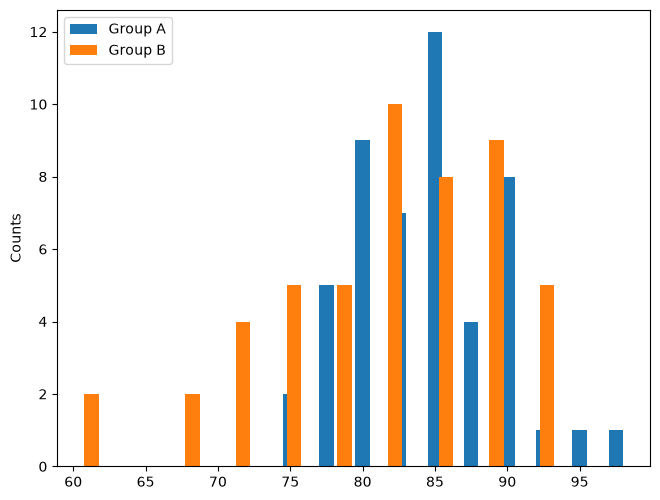

In [6]:
plt.boxplot((a,b))
plt.xlabel("Group")
plt.ylabel("Test score")
plt.savefig("hypothesis_box_plot.png", dpi=300)
plt.close()

h,x = np.histogram(a, bins=10)
plt.bar(x[:-1],h, width=0.4*(x[1]-x[0]), label='Group A')
h,y = np.histogram(b, bins=10)
plt.bar(y[:-1]+(x[1]-x[0])/2, h, width=0.4*(x[1]-x[0]), label='Group B')
plt.legend(loc='upper left')
plt.ylabel('Counts')
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
#plt.savefig("hypothesis_bar_plot.png", dpi=300)
plt.show()

## 4.6.3 맨–휘트니 U 검정
- 맨–휘트니 U 검정은 **비모수적 검정**으로, 데이터가 정규분포를 따른다는 가정을 하지 않음
- Wilcoxon rank-sum test라고도 함
- 원자료의 평균을 직접 비교하기보다, 두 집단 값을 합쳐 정렬한 뒤 **순위(rank)**를 이용
- 귀무가설은 두 집단에서 임의로 하나씩 뽑았을 때, 한 집단의 값이 다른 집단 값보다 클 확률이 0.5라는 것
- 즉 두 집단이 같은 분포에서 왔다면 어느 쪽 값이 더 클지는 대칭적이어야 함
- 정규성 가정이 불안하거나 t-검정을 적용하기 어려울 때 유용함

#### 계산 흐름
1) 두 집단의 값을 합쳐 작은 값부터 순위를 매김
2) 동점은 해당 순위들의 평균을 부여
3) 각 집단의 순의함 $R_1$, $R_2$를 구함
4) 순위합으로 $U_1$, $U_2$를 계산하고, 보통 더 작은 $U$를 검정 통계량으로 사용
$$
    U_1=n_1n_2+\frac{n_1(n_1-1)}{2}-R_1\\
    U_2=n_1n_2+\frac{n_2(n_2-1)}{2}-R_2
$$
- 표본 수는 각 집단에서 최소 2개 이상 필요
- 예제의 시험 점수에서는 $U=1503$, $p=0.08117$로, 0.05 기준에서는 귀무가설을 기각하지 못함
- 평균 차이가 커질수록 일반적으로 p값은 작아짐, 다만 **표본 크기**도 p값에 영향을 줌

In [7]:
from scipy.stats import mannwhitneyu

u,p = mannwhitneyu(a,b)
print("(U=%0.5f, p=%0.5f)" % (u,p))

(U=1503.00000, p=0.08117)


n=1000 Cohen's d = 0.12731


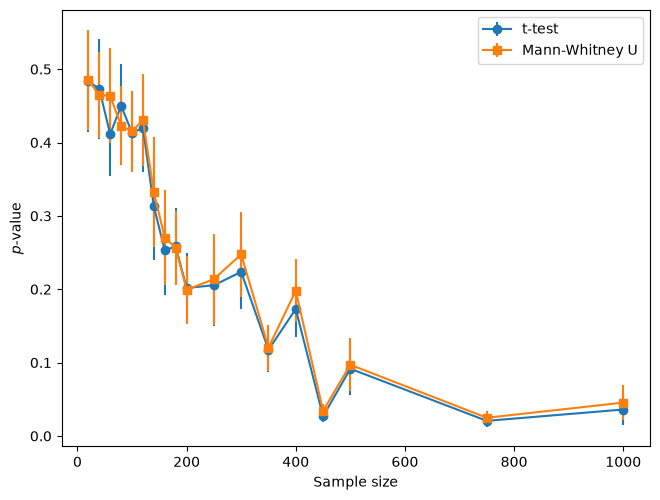

In [8]:
#  Effect of sample size
np.random.seed(65535)
pt = []
et = []
pm = []
em = []
M = 25
n = [20,40,60,80,100,120,140,160,180,200,250,300,350,400,450,500,750,1000]
for i in n:
    p = []
    t = []
    for j in range(M):
        a = np.random.normal(85,6,i).astype("int32")
        a[np.where(a > 100)] = 100
        b = np.random.normal(84,7,i).astype("int32")
        b[np.where(b > 100)] = 100
        t.append(ttest_ind(a,b,equal_var=False)[1])
        p.append(mannwhitneyu(a,b)[1])
    pt.append(np.array(t).mean())
    et.append(np.array(t).std(ddof=1)/np.sqrt(M))
    pm.append(np.array(p).mean())
    em.append(np.array(p).std(ddof=1)/np.sqrt(M))
    if (i==1000):
        print("n=1000 Cohen's d = %0.5f" % Cohen_d(a,b))
pt = np.array(pt)
pm = np.array(pm)
et = np.array(et)
em = np.array(em)
plt.errorbar(n,pt,et,marker='o',label='t-test')
plt.errorbar(n,pm,em,marker='s',label='Mann-Whitney U')
plt.xlabel('Sample size')
plt.ylabel("$p$-value")
plt.legend(loc="upper right")
plt.tight_layout(pad=0,w_pad=0,h_pad=0)
# plt.savefig("hypothesis_pvalue_plot.png", dpi=300)
plt.show()